In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries loaded!")

✅ All libraries loaded!


STEP 2: Loading **Dataset**

In [ ]:
df = pd.read_csv('/content/student_data.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (395, 33)

Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


** Step 3** **Data Explore**

In [ ]:
# Data types aur missing values
print("=== INFO ===")
df.info()

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== STATISTICS ===")
df.describe()

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 2

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


 STEP 4: **Preprocessing**

In [ ]:
# Numerical columns mein median se fill karo
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("✅ Missing values handled!")

✅ Missing values handled!


In [ ]:
# G3 >= 10 = Pass (1), warna Fail (0)
df['pass'] = (df['G3'] >= 10).astype(int)

print("Pass/Fail distribution:")
print(df['pass'].value_counts())

Pass/Fail distribution:
pass
1    265
0    130
Name: count, dtype: int64


In [ ]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(f"✅ Encoded columns: {cat_cols}")

✅ Encoded columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']


In [ ]:
X = df.drop(columns=['G3', 'pass'])
y = df['pass']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (395, 32)
y shape: (395,)


**Split aur Normalize**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"✅ Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")

✅ Train: (316, 32) | Test: (79, 32)


**STEP 5: EDA — Visualizations**

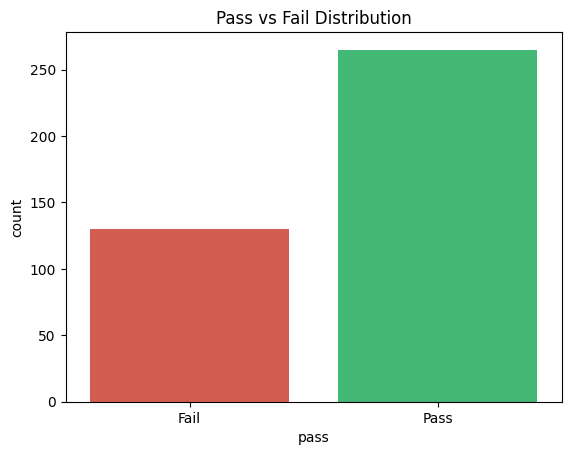

In [ ]:
sns.countplot(x='pass', data=df, palette=['#E74C3C','#2ECC71'])
plt.title('Pass vs Fail Distribution')
plt.xticks([0,1], ['Fail','Pass'])
plt.show()

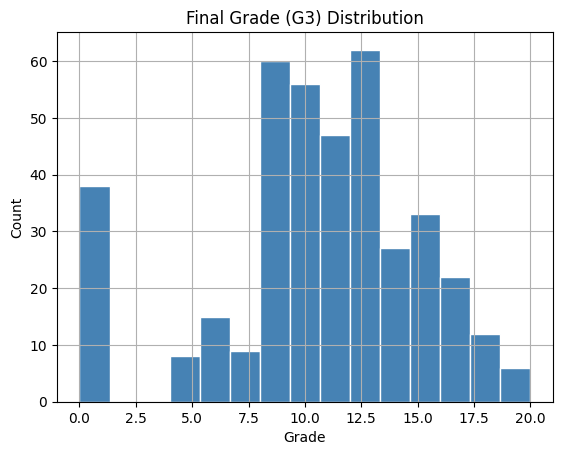

In [ ]:
df['G3'].hist(bins=15, color='steelblue', edgecolor='white')
plt.title('Final Grade (G3) Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()

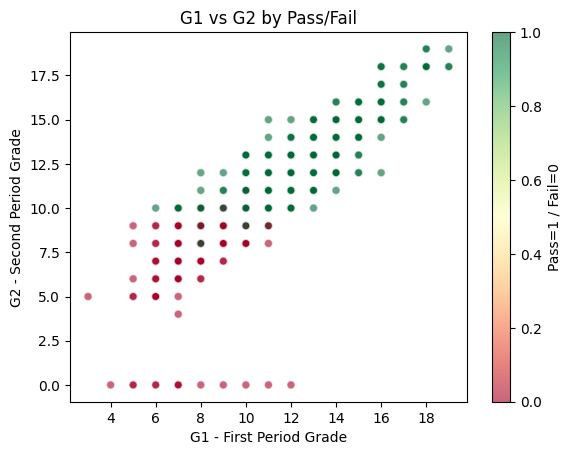

In [ ]:
plt.scatter(df['G1'], df['G2'], c=df['pass'],
            cmap='RdYlGn', alpha=0.6, edgecolors='white')
plt.xlabel('G1 - First Period Grade')
plt.ylabel('G2 - Second Period Grade')
plt.title('G1 vs G2 by Pass/Fail')
plt.colorbar(label='Pass=1 / Fail=0')
plt.show()

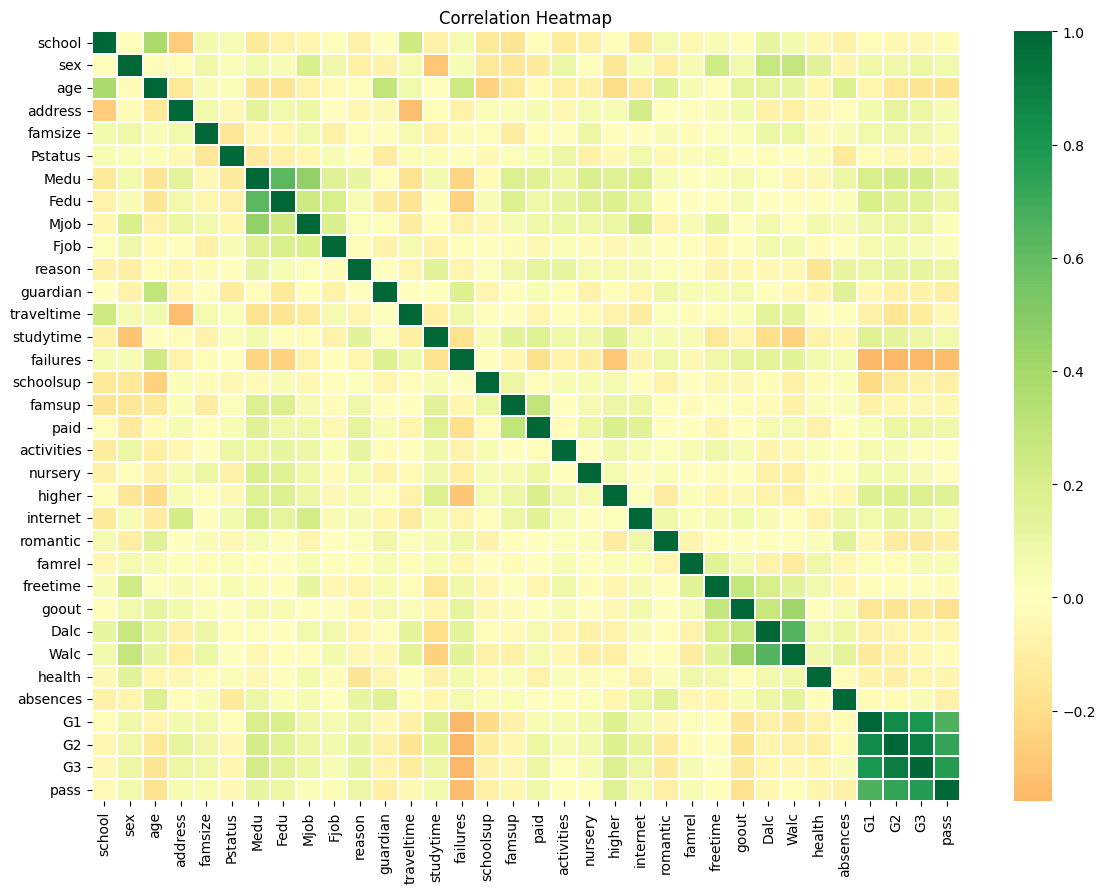

In [ ]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='RdYlGn', center=0,
            linewidths=0.3, annot=False)
plt.title('Correlation Heatmap')
plt.show()


**STEP 6: Models Training**



In [ ]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

print("✅ Logistic Regression trained!")

✅ Logistic Regression trained!


In [ ]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_sc, y_train)
y_pred_dt = dt.predict(X_test_sc)

print("✅ Decision Tree trained!")

✅ Decision Tree trained!


**STEP 7: Models Evaluate**

In [ ]:
def evaluate(name, y_true, y_pred):
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score : {f1_score(y_true, y_pred):.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=['Fail','Pass'])}")

evaluate("Logistic Regression", y_test, y_pred_lr)
evaluate("Decision Tree",       y_test, y_pred_dt)


  Logistic Regression
  Accuracy : 0.8608
  Precision: 0.9565
  Recall   : 0.8302
  F1-Score : 0.8889

              precision    recall  f1-score   support

        Fail       0.73      0.92      0.81        26
        Pass       0.96      0.83      0.89        53

    accuracy                           0.86        79
   macro avg       0.84      0.88      0.85        79
weighted avg       0.88      0.86      0.86        79


  Decision Tree
  Accuracy : 0.8861
  Precision: 0.9400
  Recall   : 0.8868
  F1-Score : 0.9126

              precision    recall  f1-score   support

        Fail       0.79      0.88      0.84        26
        Pass       0.94      0.89      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.89      0.87        79
weighted avg       0.89      0.89      0.89        79



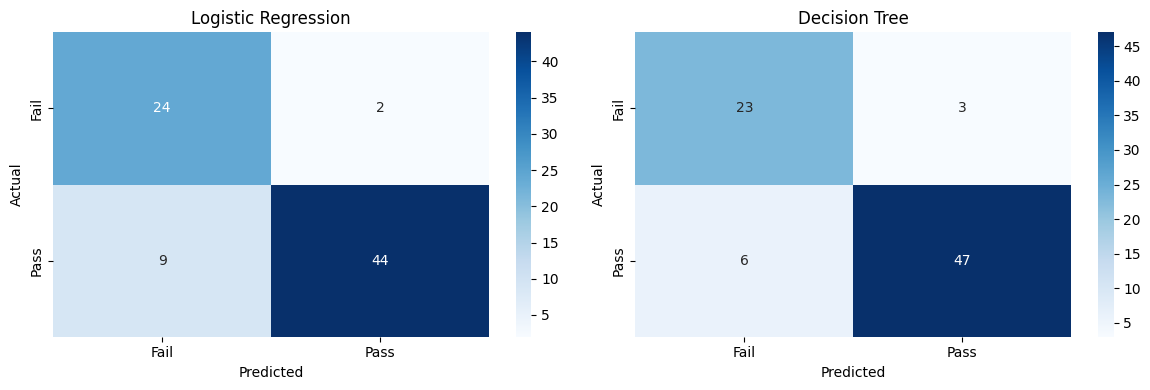

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in zip(axes,
    [y_pred_lr, y_pred_dt],
    ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fail','Pass'],
                yticklabels=['Fail','Pass'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()